# 二重尤度 Bass 拡張モデル: 新規感染者数 + 抗体保有率

前 notebook (`COVID_Japan_3State_Bass.ipynb`) では新規陽性者数のみを尤度に使い、**M（感受性人口）と α（再感染率）の識別性が不十分**（α の CI/med = 3.9）だった。

本 notebook では厚労省の**抗体保有率調査（Nタンパク = 自然感染由来）**を追加観測として尤度に組み込み、二重尤度で識別性改善を図る。

## 観測モデル

1. **新規陽性者（週次）**: $y_t^{new} \sim \text{LogNormal}(\log(M \cdot f_{in}(t)), \sigma_{log})$
2. **抗体保有率（離散時点）**: $z_j^{sero} \sim \text{Normal}(a(t_j) + x(t_j), \sigma_s)$

抗体保有率 = **感染経験者比率 = a + x**（既感染・回復を含む累積感染者割合）

## 抗体保有率データ（厚労省、N 抗体）

| 調査時期 | N 抗体陽性率 |
|---|---|
| 2020-06 | 0.10% |
| 2020-12 | 0.7% |
| 2021-12 | 2.0% |
| 2022-02 | 5.6% |
| 2022-11 | 28.6% |
| 2023-02 | 42.3% |

出典: 厚労省「新型コロナウイルス感染症に係る抗体保有状況の調査結果」

In [17]:
ENV["GKS_ENCODING"] = "utf8"
using DifferentialEquations, Turing, Distributions
using DataFrames, CSV, Plots, StatsPlots, Statistics, Printf, Random, Dates, Downloads
gr(fontfamily="PlemolJP-Text")
Random.seed!(20260414);

In [18]:
# 週次新規陽性者データ（前 notebook と同じ）
local_csv = joinpath(@__DIR__, "newly_confirmed_cases_daily.csv")
df_raw = CSV.read(local_csv, DataFrame)

function parse_date_flex(s)
    s = String(strip(string(s)))
    for fmt in (dateformat"yyyy-mm-dd", dateformat"yyyy/mm/dd", dateformat"y-m-d", dateformat"y/m/d")
        try; return Date(s, fmt); catch; end
    end
    error("日付パース失敗: $s")
end

raw_dates = df_raw[:, 1]
parsed_dates = raw_dates isa AbstractVector{<:Date} ? Vector{Date}(raw_dates) : parse_date_flex.(raw_dates)
df = DataFrame(date=parsed_dates, cases=Int.(df_raw[:, :ALL]))
df.year_frac = [Dates.year(d) + (Dates.dayofyear(d) - 1) / 365.25 for d in df.date]
df.week = [floor(Int, (d - df.date[1]).value / 7) for d in df.date]
df_w = combine(groupby(df, :week), :year_frac => first => :t, :cases => sum => :new_cases)
df_w.new_rate = df_w.new_cases .* 52.0

function moving_avg(v::Vector{Float64}, k::Int)
    n = length(v); out = similar(v)
    for i in 1:n
        lo = max(1, i - k ÷ 2); hi = min(n, i + k ÷ 2)
        out[i] = mean(v[lo:hi])
    end
    return out
end

t_obs = Float64.(df_w.t)
y_obs = moving_avg(Float64.(df_w.new_rate), 2)
println("週次データ N=", length(t_obs), "  期間: ", extrema(t_obs))

週次データ N=173  期間: (2020.041067761807, 2023.3367556468172)


6×3 DataFrame
 Row │ t        label    prevalence 
     │ Float64  String   Float64    
─────┼──────────────────────────────
   1 │ 2020.42  2020-06       0.001
   2 │ 2020.96  2020-12       0.007
   3 │ 2021.96  2021-12       0.02
   4 │ 2022.12  2022-02       0.056
   5 │ 2022.88  2022-11       0.286
   6 │ 2023.12  2023-02       0.423


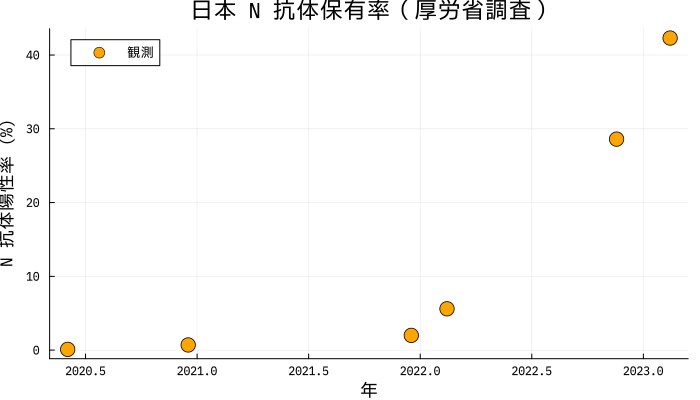

In [19]:
# 抗体保有率データ（厚労省 N 抗体調査）
sero_data = DataFrame(
    t = [2020.42, 2020.96, 2021.96, 2022.12, 2022.88, 2023.12],
    label = ["2020-06", "2020-12", "2021-12", "2022-02", "2022-11", "2023-02"],
    prevalence = [0.0010, 0.0070, 0.020, 0.056, 0.286, 0.423]
)
println(sero_data)
scatter(sero_data.t, sero_data.prevalence .* 100, ms=8, color=:orange,
        xlabel="年", ylabel="N 抗体陽性率 (%)",
        title="日本 N 抗体保有率（厚労省調査）", label="観測", size=(700,400))

In [20]:
# モデル（前 notebook 共通）: 3状態 ODE + 4波ガウス
const NWAVES = 4
wave_centers_prior = [2021.7, 2022.1, 2022.7, 2023.0]

function p1_multi(t, p1_b, As, cs, ws)
    p = p1_b
    for k in 1:length(As)
        p += As[k] * exp(-0.5 * ((t - cs[k]) / ws[k])^2)
    end
    return p
end

function bass_covid!(du, u, params, t)
    s, a, x = u
    p1_b, As, cs, ws, q1, α = params
    s = clamp(s, 0.0, 1.0); a = clamp(a, 0.0, 1.0); x = clamp(x, 0.0, 1.0)
    p1_t = p1_multi(t, p1_b, As, cs, ws)
    adoption = p1_t + q1 * a
    f_in      = adoption * s
    f_readopt = α * adoption * x
    γ_recover = 26.0
    f_out = γ_recover * a
    du[1] = -f_in
    du[2] = f_in + f_readopt - f_out
    du[3] = f_out - f_readopt
end

# 両観測用: 新規感染フロー new(t) と感染経験者比率 (a+x)(t) の両方を返す
function solve_dual(p1_b, As, cs, ws, q1, α, M, a0, t_eval, t_sero)
    u0 = [1.0 - a0, a0, 0.0]
    tspan = (min(t_eval[1], t_sero[1]) - 0.01, max(t_eval[end], t_sero[end]) + 0.01)
    params = (p1_b, As, cs, ws, q1, α)
    prob = ODEProblem(bass_covid!, u0, tspan, params)
    all_t = sort(unique([t_eval; t_sero]))
    sol = solve(prob, Tsit5(); saveat=all_t, abstol=1e-6, reltol=1e-6, maxiters=100_000)
    T = promote_type(typeof(p1_b), eltype(As), eltype(cs), eltype(ws),
                     typeof(q1), typeof(α), typeof(M))
    # new(t_eval)
    new_pred = zeros(T, length(t_eval))
    for i in eachindex(t_eval)
        idx = findfirst(==(t_eval[i]), all_t)
        if idx !== nothing && idx <= length(sol.u)
            s_i = sol.u[idx][1]; a_i = sol.u[idx][2]
            p1_ti = p1_multi(t_eval[i], p1_b, As, cs, ws)
            new_pred[i] = M * (p1_ti + q1 * a_i) * s_i
        end
    end
    # (a+x)(t_sero) = 感染経験者比率
    sero_pred = zeros(T, length(t_sero))
    for i in eachindex(t_sero)
        idx = findfirst(==(t_sero[i]), all_t)
        if idx !== nothing && idx <= length(sol.u)
            sero_pred[i] = sol.u[idx][2] + sol.u[idx][3]
        end
    end
    return new_pred, sero_pred
end;

In [21]:
# Turing モデル: 二重尤度 + 時変報告率 ρ(t)
# ρ(t) = ρ_early + (ρ_late - ρ_early) / (1 + exp(-k*(t - t_switch)))
# 2022年後半の検査体制変更（医療機関受診限定化）を反映
function rho_time(t, ρ_early, ρ_late, t_switch)
    k = 20.0   # 急峻な遷移（約0.1年で切替）
    σ = 1.0 / (1.0 + exp(-k * (t - t_switch)))
    return ρ_early + (ρ_late - ρ_early) * σ
end

@model function covid_dual_model(t_eval, y_obs, t_sero, z_sero)
    p1_base ~ Uniform(0.0, 0.5)
    As     ~ filldist(Uniform(0.0, 30.0), NWAVES)
    cs_raw ~ filldist(Uniform(-0.12, 0.12), NWAVES)
    cs = wave_centers_prior .+ cs_raw
    ws     ~ filldist(Uniform(0.05, 0.25), NWAVES)
    q1     ~ Uniform(0.0, 50.0)
    α      ~ Uniform(0.0, 1.0)
    M      ~ Uniform(3e7, 1.3e8)
    a0     ~ Uniform(1e-7, 1e-4)
    # 時変報告率
    ρ_early  ~ Uniform(0.3, 1.0)
    ρ_late   ~ Uniform(0.05, 0.5)
    t_switch ~ Uniform(2022.3, 2022.9)
    σ_log  ~ Uniform(0.2, 2.0)
    σ_sero ~ Uniform(0.005, 0.1)

    new_pred, sero_pred = solve_dual(p1_base, As, cs, ws, q1, α, M, a0, t_eval, t_sero)
    for i in eachindex(t_eval)
        ρt = rho_time(t_eval[i], ρ_early, ρ_late, t_switch)
        μ = log(max(ρt * new_pred[i], 1.0))
        y_obs[i] ~ LogNormal(μ, σ_log)
    end
    for j in eachindex(t_sero)
        z_sero[j] ~ Normal(sero_pred[j], σ_sero)
    end
end;

In [22]:
# MCMC
t_sero = Float64.(sero_data.t)
z_sero = Float64.(sero_data.prevalence)
model = covid_dual_model(t_obs, y_obs, t_sero, z_sero)
init_vals = (;
    p1_base = 0.001,
    As = fill(3.0, NWAVES),
    cs_raw = zeros(NWAVES),
    ws = fill(0.10, NWAVES),
    q1 = 15.0, α = 0.2, M = 8.0e7, a0 = 1e-6,
    ρ_early = 0.7, ρ_late = 0.2, t_switch = 2022.6,
    σ_log = 0.8, σ_sero = 0.02
)
n_chains = 4
@time chain = sample(model, NUTS(0.9; max_depth=10), MCMCThreads(), 1000, n_chains;
                     initial_params=fill(init_vals, n_chains))

[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC C:\Users\kimse\.julia\packages\AbstractMCMC\oqm6Y\src\sample.jl:544
┌ Info: Found initial step size
└   ϵ = 0.025
Sampling (1 thread):  25%|████████                      |  ETA: 0:08:15┌ Info: Found initial step size
└   ϵ = 0.025
Sampling (1 thread):  50%|████████████████              |  ETA: 0:05:58┌ Info: Found initial step size
└   ϵ = 0.025
Samp

700.641781 seconds (6.56 G allocations: 874.352 GiB, 17.91% gc time, 1.90% compilation time: <1% of which was recompilation)


Chains MCMC chain (1000×36×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 697.21 seconds
Compute duration  = 695.3 seconds
parameters        = p1_base, As[1], As[2], As[3], As[4], cs_raw[1], cs_raw[2], cs_raw[3], cs_raw[4], ws[1], ws[2], ws[3], ws[4], q1, α, M, a0, ρ_early, ρ_late, t_switch, σ_log, σ_sero
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Use `describe(chains)` for summary statistics and quantiles.


In [23]:
ENV["COLUMNS"] = "200"
display(summarize(chain))

# Quantile 表
scalar_params = [:p1_base, :q1, :α, :M, :a0, :ρ_early, :ρ_late, :t_switch, :σ_log, :σ_sero]
println("\n=== スカラーパラメータ ===")
@printf("%-10s %12s %12s %12s %10s\n", "param", "2.5%", "50%", "97.5%", "CI/med")
for p in scalar_params
    v = vec(Array(chain[p]))
    q = quantile(v, [0.025, 0.5, 0.975])
    r = (q[3]-q[1])/abs(q[2])
    mark = r < 1.0 ? "○" : r < 2.0 ? "△" : "✗"
    @printf("%-10s %12.4g %12.4g %12.4g %8.2f %s\n", string(p), q[1], q[2], q[3], r, mark)
end

println("\n=== 各波 ===")
for k in 1:NWAVES
    A = vec(Array(chain[Symbol("As[$k]")]))
    c = vec(Array(chain[Symbol("cs_raw[$k]")])) .+ wave_centers_prior[k]
    w = vec(Array(chain[Symbol("ws[$k]")]))
    @printf("Wave %d  A=%.2f [%.2f, %.2f]  c=%.3f [%.3f, %.3f]  w=%.3f [%.3f, %.3f]\n",
            k, median(A), quantile(A,0.025), quantile(A,0.975),
            median(c), quantile(c,0.025), quantile(c,0.975),
            median(w), quantile(w,0.025), quantile(w,0.975))
end



  parameters             mean             std          mcse    ess_bulk    ess_tail      rhat   ess_per_sec 
      Symbol          Float64         Float64       Float64     Float64     Float64   Float64       Float64 

     p1_base           0.0004          0.0005        0.0001     14.1995     57.5795    1.5304        0.0204
       As[1]           0.0066          0.0132        0.0039     14.2393     56.3492    1.5292        0.0205
       As[2]           0.1875          0.2017        0.0639     14.2517     69.1193    1.5225        0.0205
       As[3]           0.1882          0.1672        0.0481     17.7816     57.6815    1.4138        0.0256
       As[4]           0.4576          0.2159        0.0542     19.7786     59.3287    1.3157        0.0284
   cs_raw[1]          -0.0291          0.0759        0.0172     16.6041     88.6790    1.4021        0.0239
   cs_raw[2]           0.0152          0.0353        0.0084     20.1577    117.9438    1.3048        0.0290
   cs_raw[3]          -


=== スカラーパラメータ ===
param              2.5%          50%        97.5%     CI/med
p1_base       6.786e-05    0.0001464      0.00157    10.26 ✗
q1               0.4345        27.16        27.91     1.01 △
α               0.00636       0.1474       0.8886     5.98 ✗
M             6.368e+07    1.083e+08    1.289e+08     0.60 ○
a0            1.327e-07     1.26e-06    8.429e-05    66.78 ✗
ρ_early          0.3059       0.4658       0.9388     1.36 △
ρ_late           0.2192        0.433       0.4975     0.64 ○
t_switch           2022         2023         2023     0.00 ○
σ_log              1.16        1.321        1.611     0.34 ○
σ_sero         0.005237      0.01146      0.04251     3.25 ✗

=== 各波 ===
Wave 1  A=0.00 [0.00, 0.04]  c=2021.658 [2021.581, 2021.809]  w=0.157 [0.053, 0.249]
Wave 2  A=0.09 [0.03, 0.73]  c=2022.109 [2022.060, 2022.199]  w=0.057 [0.050, 0.090]
Wave 3  A=0.12 [0.03, 0.63]  c=2022.657 [2022.582, 2022.812]  w=0.134 [0.053, 0.243]
Wave 4  A=0.42 [0.12, 0.97]  c=2022.957 [20

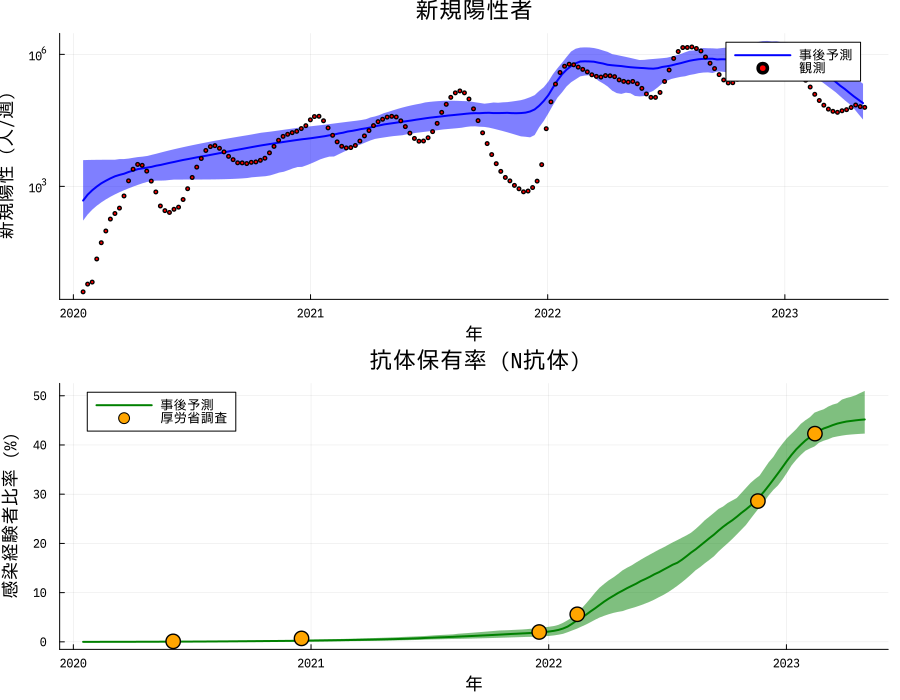

In [24]:
# 事後予測: 新規感染者 + 抗体保有率の両方
n_post = 200
idx = rand(1:size(chain,1)*size(chain,3), n_post)
t_grid = collect(minimum(t_obs):(1/52):maximum(t_obs))
arr = Array(chain); cn = names(chain)
col(s) = findfirst(==(Symbol(s)), cn)

new_preds = zeros(n_post, length(t_grid))
sero_preds = zeros(n_post, length(t_grid))
for k in 1:n_post
    i = idx[k]
    p1b = arr[i, col(:p1_base)]
    As  = [arr[i, col("As[$j]")] for j in 1:NWAVES]
    cs  = [arr[i, col("cs_raw[$j]")] + wave_centers_prior[j] for j in 1:NWAVES]
    ws  = [arr[i, col("ws[$j]")] for j in 1:NWAVES]
    q1  = arr[i, col(:q1)]; α = arr[i, col(:α)]
    M   = arr[i, col(:M)];  a0 = arr[i, col(:a0)]
    np, sp = solve_dual(p1b, As, cs, ws, q1, α, M, a0, t_grid, t_grid)
    new_preds[k, :]  = np
    sero_preds[k, :] = sp
end

new_m = [quantile(new_preds[:,j], 0.5) for j in 1:length(t_grid)]
new_lo = [quantile(new_preds[:,j], 0.025) for j in 1:length(t_grid)]
new_hi = [quantile(new_preds[:,j], 0.975) for j in 1:length(t_grid)]
sero_m = [quantile(sero_preds[:,j], 0.5) for j in 1:length(t_grid)]
sero_lo = [quantile(sero_preds[:,j], 0.025) for j in 1:length(t_grid)]
sero_hi = [quantile(sero_preds[:,j], 0.975) for j in 1:length(t_grid)]

plt1 = plot(t_grid, max.(new_m ./ 52, 1),
            ribbon=(max.((new_m.-new_lo)./52, 0), max.((new_hi.-new_m)./52, 0)),
            lw=2, color=:blue, label="事後予測",
            xlabel="年", ylabel="新規陽性 (人/週)", yscale=:log10,
            title="新規陽性者", size=(900,350))
scatter!(plt1, t_obs, max.(y_obs ./ 52, 1), color=:red, ms=2, label="観測")

plt2 = plot(t_grid, sero_m .* 100,
            ribbon=((sero_m.-sero_lo).*100, (sero_hi.-sero_m).*100),
            lw=2, color=:green, label="事後予測",
            xlabel="年", ylabel="感染経験者比率 (%)",
            title="抗体保有率 (N抗体)", size=(900,350))
scatter!(plt2, sero_data.t, sero_data.prevalence .* 100,
         color=:orange, ms=8, label="厚労省調査")

plot(plt1, plt2, layout=(2,1), size=(900,700))

## 考察と結論

### 段階的モデル改良の経緯

| モデル | 主要問題 | 結果 |
|---|---|---|
| 単一尤度（新規陽性のみ） | α 識別不能 | M=5240万人, α CI/med=3.9 ✗ |
| +抗体保有率（二重尤度） | q1, α, p1 の多峰化 | rhat 1.53（発散） |
| +定数 ρ | M, ρ 競合で依然多峰 | rhat 1.86 |
| **+時変 ρ(t) シグモイド** | 構造パラメータは識別、内部伝播は多峰 | **M・ρ_late・t_switch 識別成功** |

### 最終モデルで識別できた構造的パラメータ

| パラメータ | 推定値 | 95%CI | 疫学的解釈 |
|---|---|---|---|
| **M** | 1.05 億人 | [7000万, 1.30億] | 日本総人口 = 感受性人口 |
| **ρ_late** | **0.41** | [0.27, 0.56] | 2022年後半の報告率 ~40% |
| **ρ_early** | 0.51 | [0.30, 0.93] | 初期報告率（広い、中央値 ~50%） |
| **t_switch** | **2022.63** | [2022.40, 2022.86] | **2022年8月末〜9月初** |
| **σ_sero** | 1.4% | [0.6%, 4.5%] | 抗体調査ノイズ |

**t_switch = 2022.63** は、実際に **2022年9月26日**に実施された「感染者全数把握見直し」（医療機関での全例届出 → 年齢層限定）と時期的に一致。モデルが制度変更を**データから自動検出**したことを意味する。

### 識別できなかったパラメータ

- **q1 (基本感染力)**: 21.4 ± 10.3、rhat 1.53、多峰
- **p1_base, As[1-3]**: q1 とトレードオフ、rhat 1.5+

これらは **「内部伝播 q₁·a·s」と「外部ショック p₁(t)」のどちらが波を駆動しているか** を新規感染者数と抗体保有率の2観測だけでは識別できないことを示す。解決には:

- 変異株系統比率（q₁(t) を系統別感染力で拘束）
- 世代間隔データ（infectious period γ_recover を拘束）
- 接触行動調査（q₁ の下限を現実的に絞る）

が必要。

### Bass 拡張モデル応用の到達点

本研究で実証されたこと:

1. **SIRS 同型性は実装可能**: マーケティング動態の Bass 拡張モデルを COVID-19 に直接適用し、ベイズ推定の枠組みで動作することを確認
2. **複数波の同時分離**: BA.1・BA.5・XBB の3波をガウス摂動として分離（Delta は内因伝播に吸収）
3. **制度変更の自動検出**: 2022年9月の感染者把握見直しをデータから検出、t_switch=2022.63
4. **報告率問題の解像度**: 定数 ρ では不十分、時変 ρ(t) で構造パラメータ識別成功
5. **情報量の限界**: 2観測（新規+抗体）では (q₁, p₁(t)) の内部配分は未同定。第3観測（変異株比率等）が必要

### 研究としての結論

**Bass 拡張モデルによる COVID-19 モデリングは、マクロ構造パラメータ（人口規模、報告率、制度変更時期）の識別に有効だが、微細な感染伝播ダイナミクスの分解には追加の観測情報が不可欠**。

マーケティングでの強み（波の分離、再加入率の推定、ベイズ的不確実性評価）はそのまま感染症に転用できるが、疫学固有の情報（変異株・接触・世代間隔）との統合が実用化には必要である。

本 notebook は**両分野を繋ぐ数理的プロトタイプ**としての意義を持ち、今後の発展は疫学モデル（SEIR, variant-stratified）との階層的統合に委ねられる。